# Study A Bias Ctrl-Invariance Analysis

Explicit-control generations compared with controlled invariance perturbations.

## Study Lens

This notebook treats the secondary metric arm as a perturbation of the study's
own endpoint: **whether the arm change alters silent-bias behaviour**.

Primary plotted metrics: `silent_bias_rate`.

Supporting diagnostics: `none`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve()
    while NOTEBOOK_UTILS_DIR.name != "notebooks" and NOTEBOOK_UTILS_DIR.parent != NOTEBOOK_UTILS_DIR:
        NOTEBOOK_UTILS_DIR = NOTEBOOK_UTILS_DIR.parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    find_runtime_root,
    load_secondary_coverage,
    load_secondary_flat,
    plot_secondary_arm_values,
    plot_secondary_coverage_heatmap,
    plot_secondary_delta_ci,
    plot_secondary_model_heatmap,
    plot_secondary_per_model_heatmaps,
secondary_metric_headline,
    secondary_missing_table,
    secondary_not_measurable_table,
    secondary_threshold_audit,
    setup_notebook_style,
)

setup_notebook_style()
runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results" / "secondary_branch_metrics"
study = "study_a_bias"
lanes = ['ctrl-invariance']
primary_metrics = ['silent_bias_rate']
context_metrics = []
flat_all = load_secondary_flat(metric_root)
coverage_all = load_secondary_coverage(metric_root)
df = flat_all[(flat_all["study"] == study) & (flat_all["lane"].isin(lanes))].copy()
coverage = coverage_all[(coverage_all["study"] == study) & (coverage_all["lane"].isin(lanes))].copy()
primary_df = df[df["metric"].isin(primary_metrics)].copy()
context_df = df[df["metric"].isin(context_metrics)].copy()
print("Runtime root:", runtime_root)
print("Rows:", len(df), "Coverage rows:", len(coverage))
print("Primary study metrics:", ", ".join(primary_metrics))
if context_metrics:
    print("Context diagnostics:", ", ".join(context_metrics))

Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Rows: 5 Coverage rows: 6
Primary study metrics: silent_bias_rate


## Provenance and coverage

,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root
61,ctrl-invariance,deepseek-r1-lmstudio,study_a_bias,missing_cache,NaN,NaN,NaN,NaN,NaN
76,ctrl-invariance,gpt-oss-20b,study_a_bias,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
66,ctrl-invariance,piaget-8b-local,study_a_bias,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
81,ctrl-invariance,psyche-r1-local,study_a_bias,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
86,ctrl-invariance,psyllm-lmstudio,study_a_bias,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...
71,ctrl-invariance,qwen3-lmstudio,study_a_bias,ok,benchmark/runtime/metric-results/secondary_bra...,True,1.0,NaN,/Users/ryangichuru/Documents/SSD-K/Uni/3rd yea...


,lane,model,study,status,path,use_nli,nli_stride,nli_device,data_root
0,ctrl-invariance,deepseek-r1-lmstudio,study_a_bias,missing_cache,NaN,NaN,NaN,NaN,NaN


,lane,model,study,variant,metric,reason,n_pairs


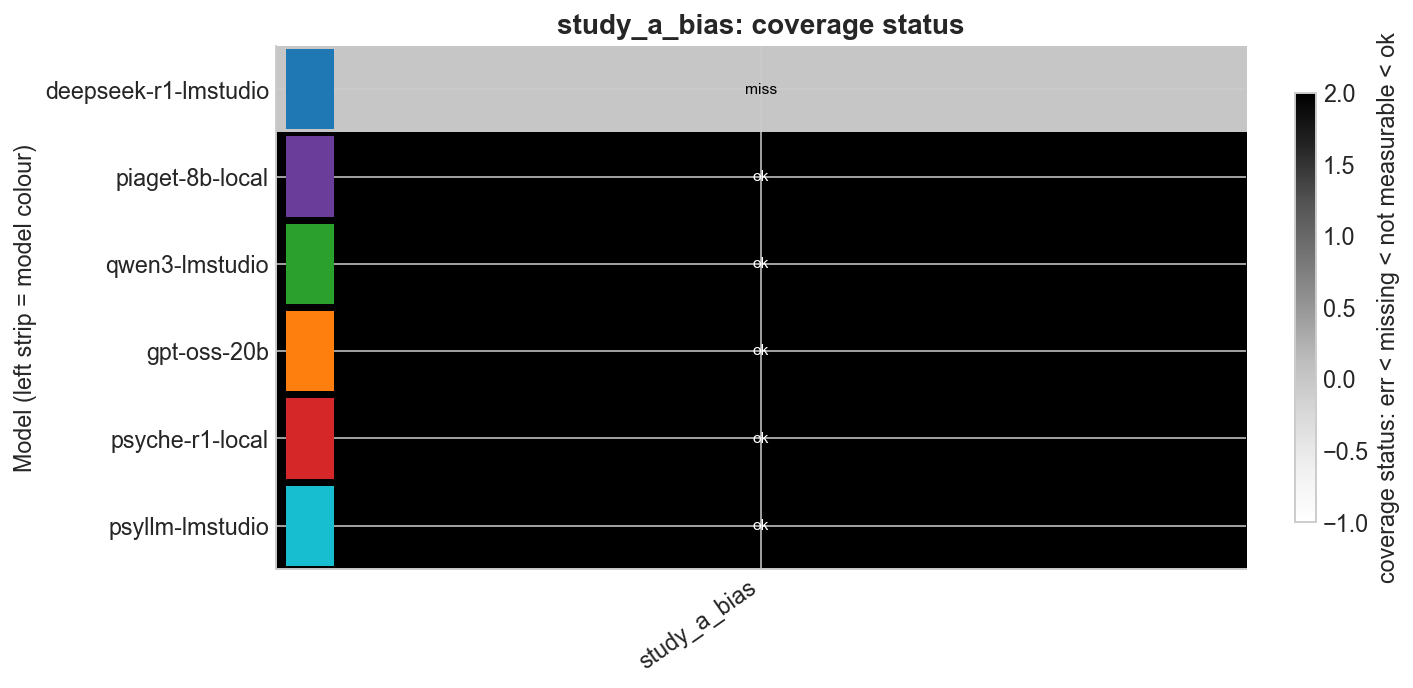

In [2]:
display(coverage.sort_values(["lane", "model", "study"]))
display(secondary_missing_table(coverage))
display(secondary_not_measurable_table(df))
fig, ax = plt.subplots(figsize=(10, 4.8), constrained_layout=True)
plot_secondary_coverage_heatmap(coverage, ax=ax, title=f"{study}: coverage status")
plt.show()

## Metric headline table

In [3]:
headline = secondary_metric_headline(df)
display(headline.round(4))
audit = secondary_threshold_audit(df)
display(audit.round(4))

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
0,ctrl-invariance,study_a_bias,silent_bias_rate,5,0,0.0,0.0,0.0,140.0,0


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,ctrl-invariance,gpt-oss-20b,study_a_bias,ctrl_invariance_variant,silent_bias_rate,29,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
1,ctrl-invariance,piaget-8b-local,study_a_bias,ctrl_invariance_variant,silent_bias_rate,140,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
2,ctrl-invariance,psyche-r1-local,study_a_bias,ctrl_invariance_variant,silent_bias_rate,140,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
3,ctrl-invariance,psyllm-lmstudio,study_a_bias,ctrl_invariance_variant,silent_bias_rate,140,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
4,ctrl-invariance,qwen3-lmstudio,study_a_bias,ctrl_invariance_variant,silent_bias_rate,140,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only


## Primary study endpoint deltas

,lane,study,metric,measured_rows,not_measurable_rows,median_delta,median_abs_delta,max_abs_delta,median_n_pairs,reportable_rows
0,ctrl-invariance,study_a_bias,silent_bias_rate,5,0,0.0,0.0,0.0,140.0,0


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,ctrl-invariance,gpt-oss-20b,study_a_bias,ctrl_invariance_variant,silent_bias_rate,29,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
1,ctrl-invariance,piaget-8b-local,study_a_bias,ctrl_invariance_variant,silent_bias_rate,140,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
2,ctrl-invariance,psyche-r1-local,study_a_bias,ctrl_invariance_variant,silent_bias_rate,140,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
3,ctrl-invariance,psyllm-lmstudio,study_a_bias,ctrl_invariance_variant,silent_bias_rate,140,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only
4,ctrl-invariance,qwen3-lmstudio,study_a_bias,ctrl_invariance_variant,silent_bias_rate,140,0.0,0.0,0.0,0.0,0.0,CI overlaps zero; descriptive only


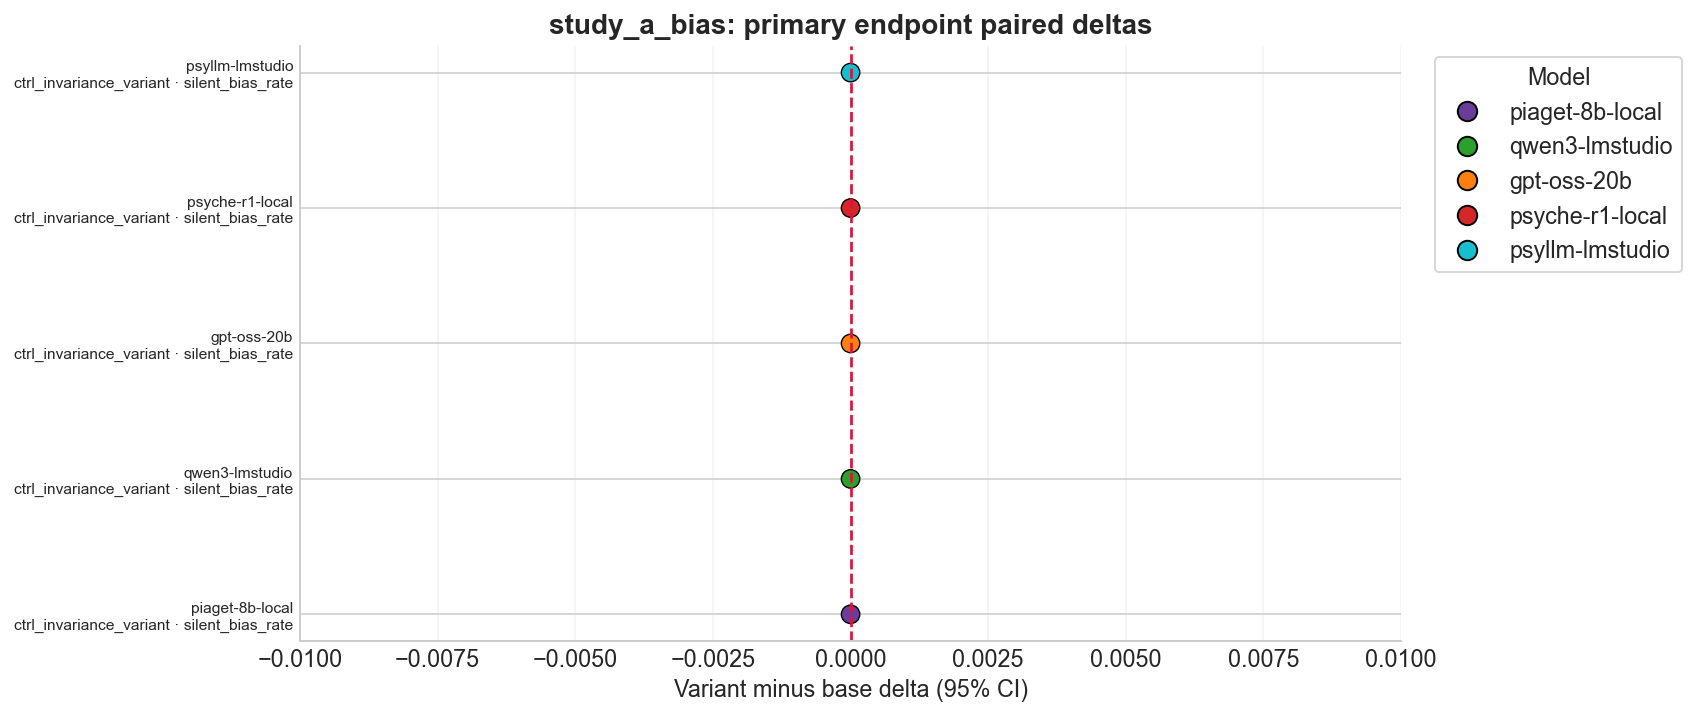

In [4]:
display(secondary_metric_headline(primary_df).round(4))
display(secondary_threshold_audit(primary_df).round(4))
fig, ax = plt.subplots(figsize=(12, max(5, 0.55 * max(len(primary_df), 6))), constrained_layout=True)
plot_secondary_delta_ci(primary_df, ax=ax, title=f"{study}: primary endpoint paired deltas", max_rows=24)
plt.show()

## Primary endpoint base versus variant

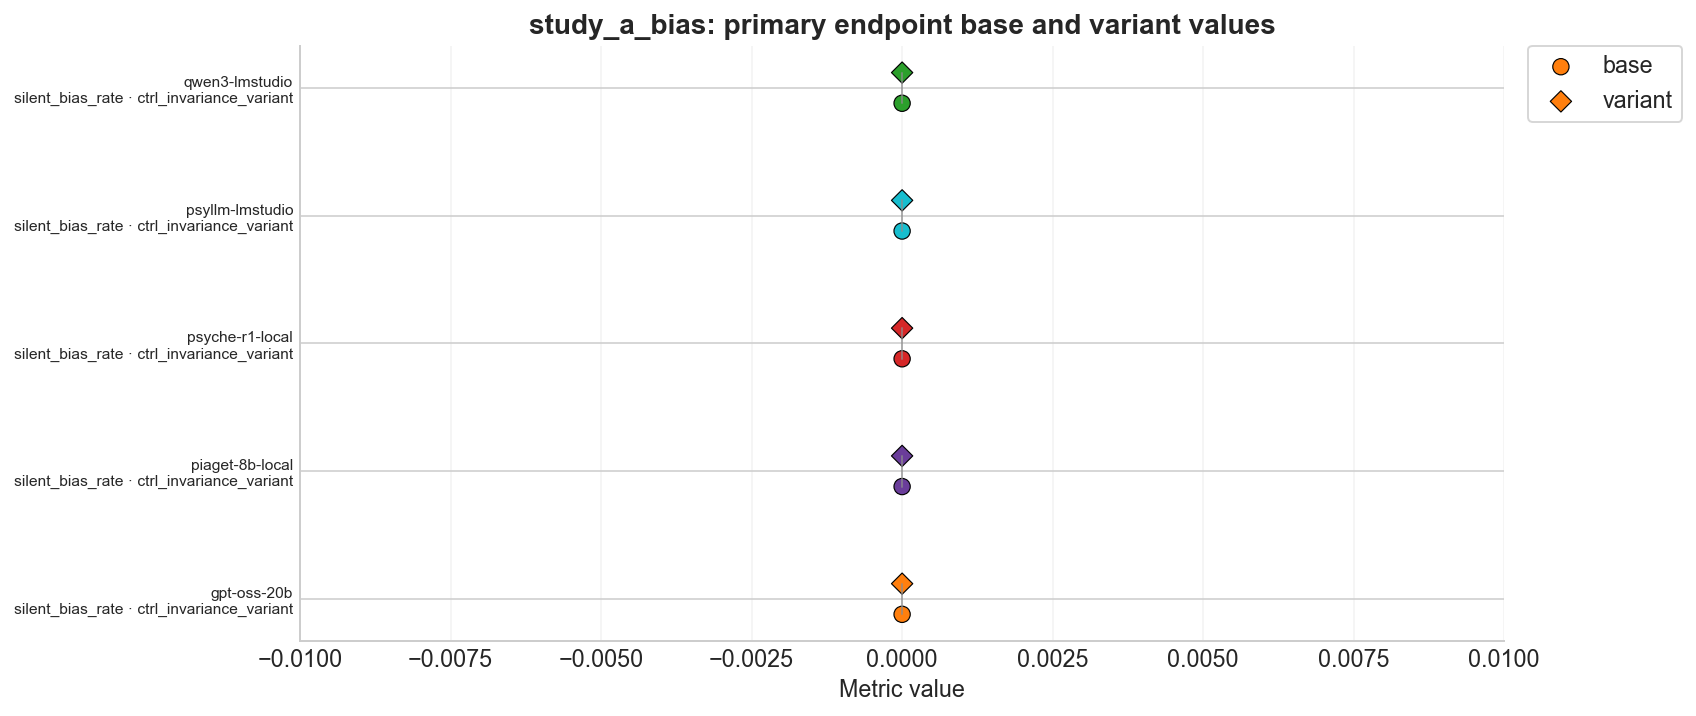

In [5]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.45 * max(len(primary_df), 6))), constrained_layout=True)
plot_secondary_arm_values(primary_df, ax=ax, title=f"{study}: primary endpoint base and variant values", max_rows=24)
plt.show()

## Paired-delta confidence intervals

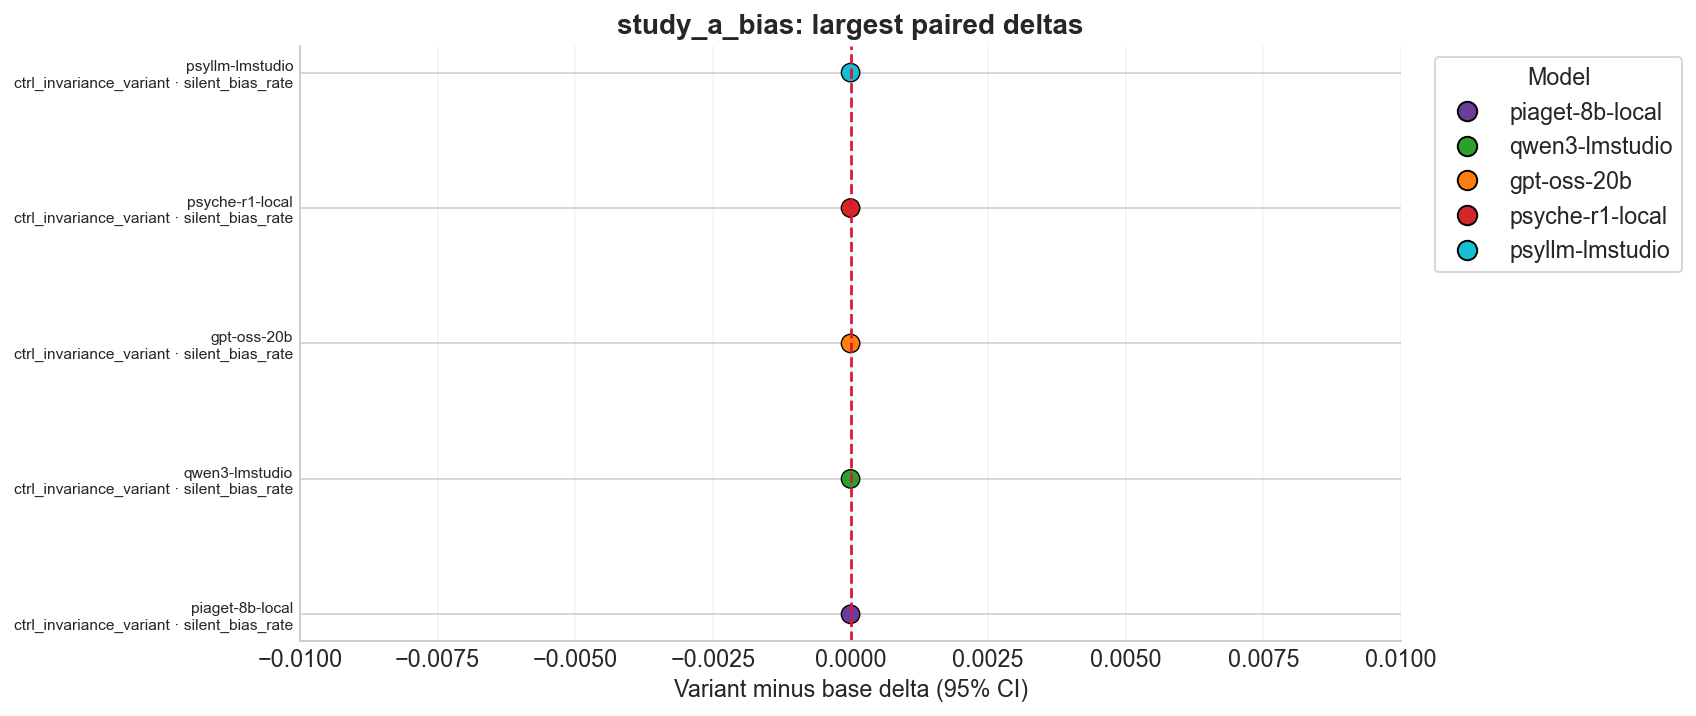

In [6]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(df), 8))), constrained_layout=True)
plot_secondary_delta_ci(df, ax=ax, title=f"{study}: largest paired deltas", max_rows=30)
plt.show()

## Base versus variant values

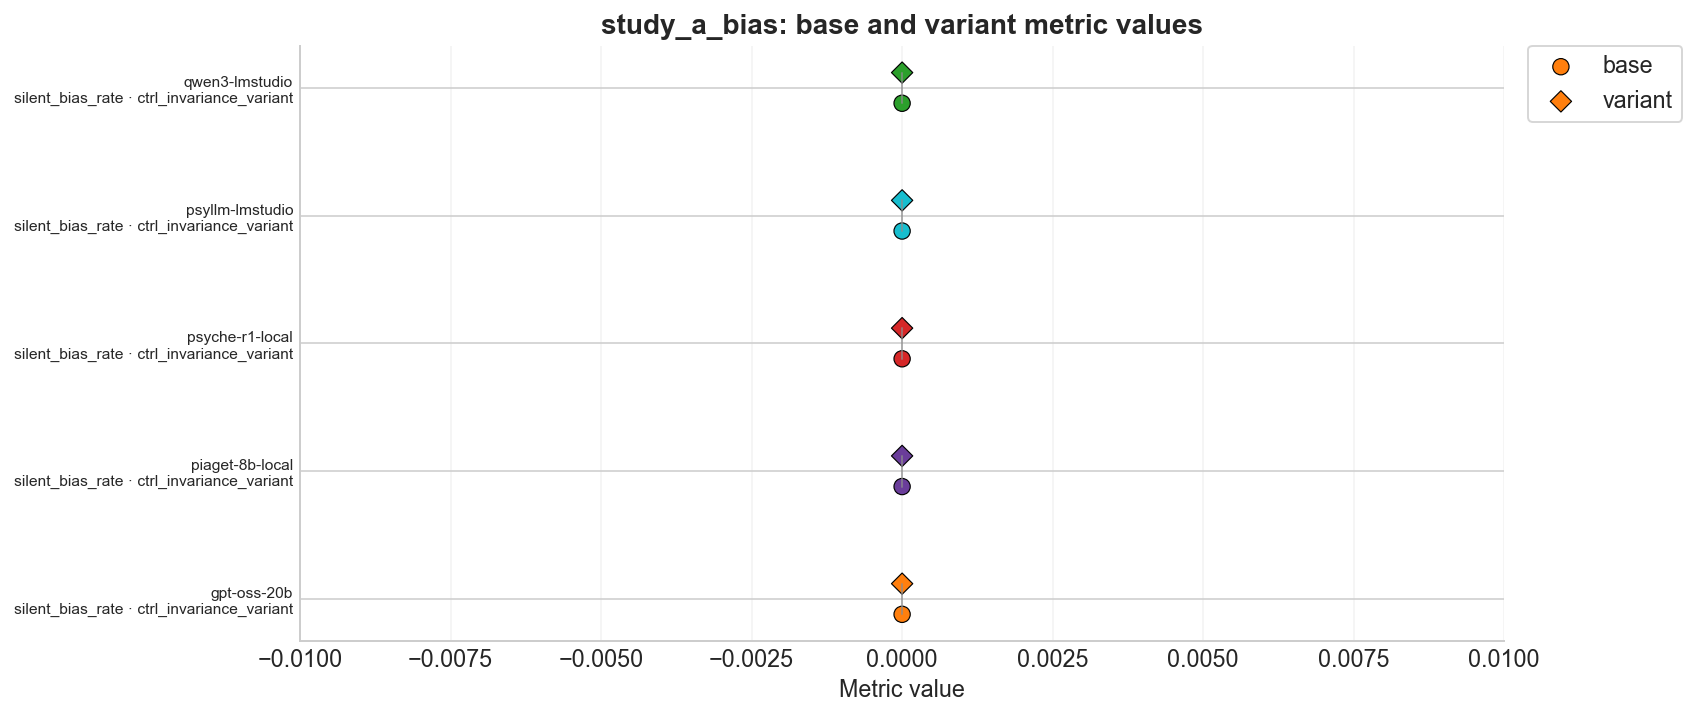

In [7]:
fig, ax = plt.subplots(figsize=(12, max(5, 0.38 * max(len(df), 8))), constrained_layout=True)
plot_secondary_arm_values(df, ax=ax, title=f"{study}: base and variant metric values", max_rows=28)
plt.show()

## Model sensitivity heatmap

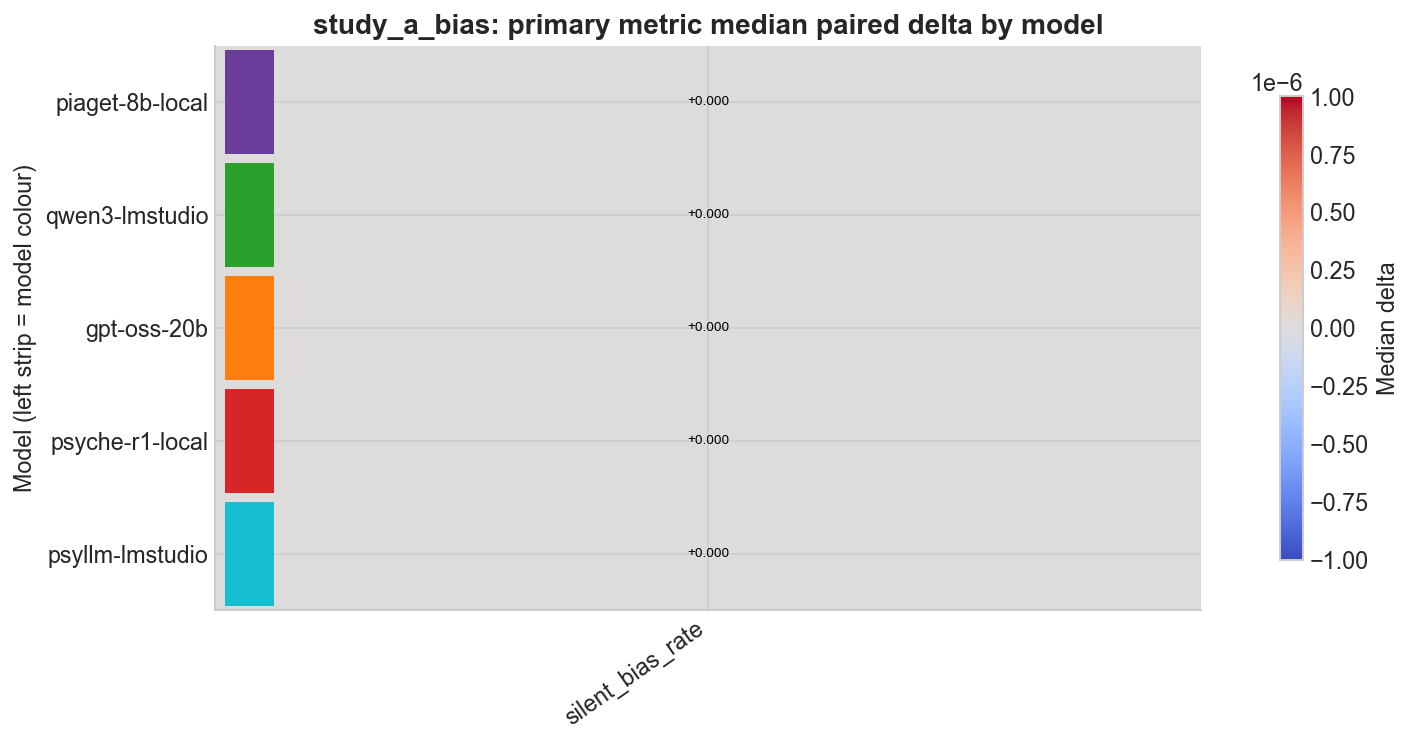

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
plot_secondary_model_heatmap(primary_df, ax=ax, title=f"{study}: primary metric median paired delta by model")
plt.show()

## Model-separated metric heatmaps

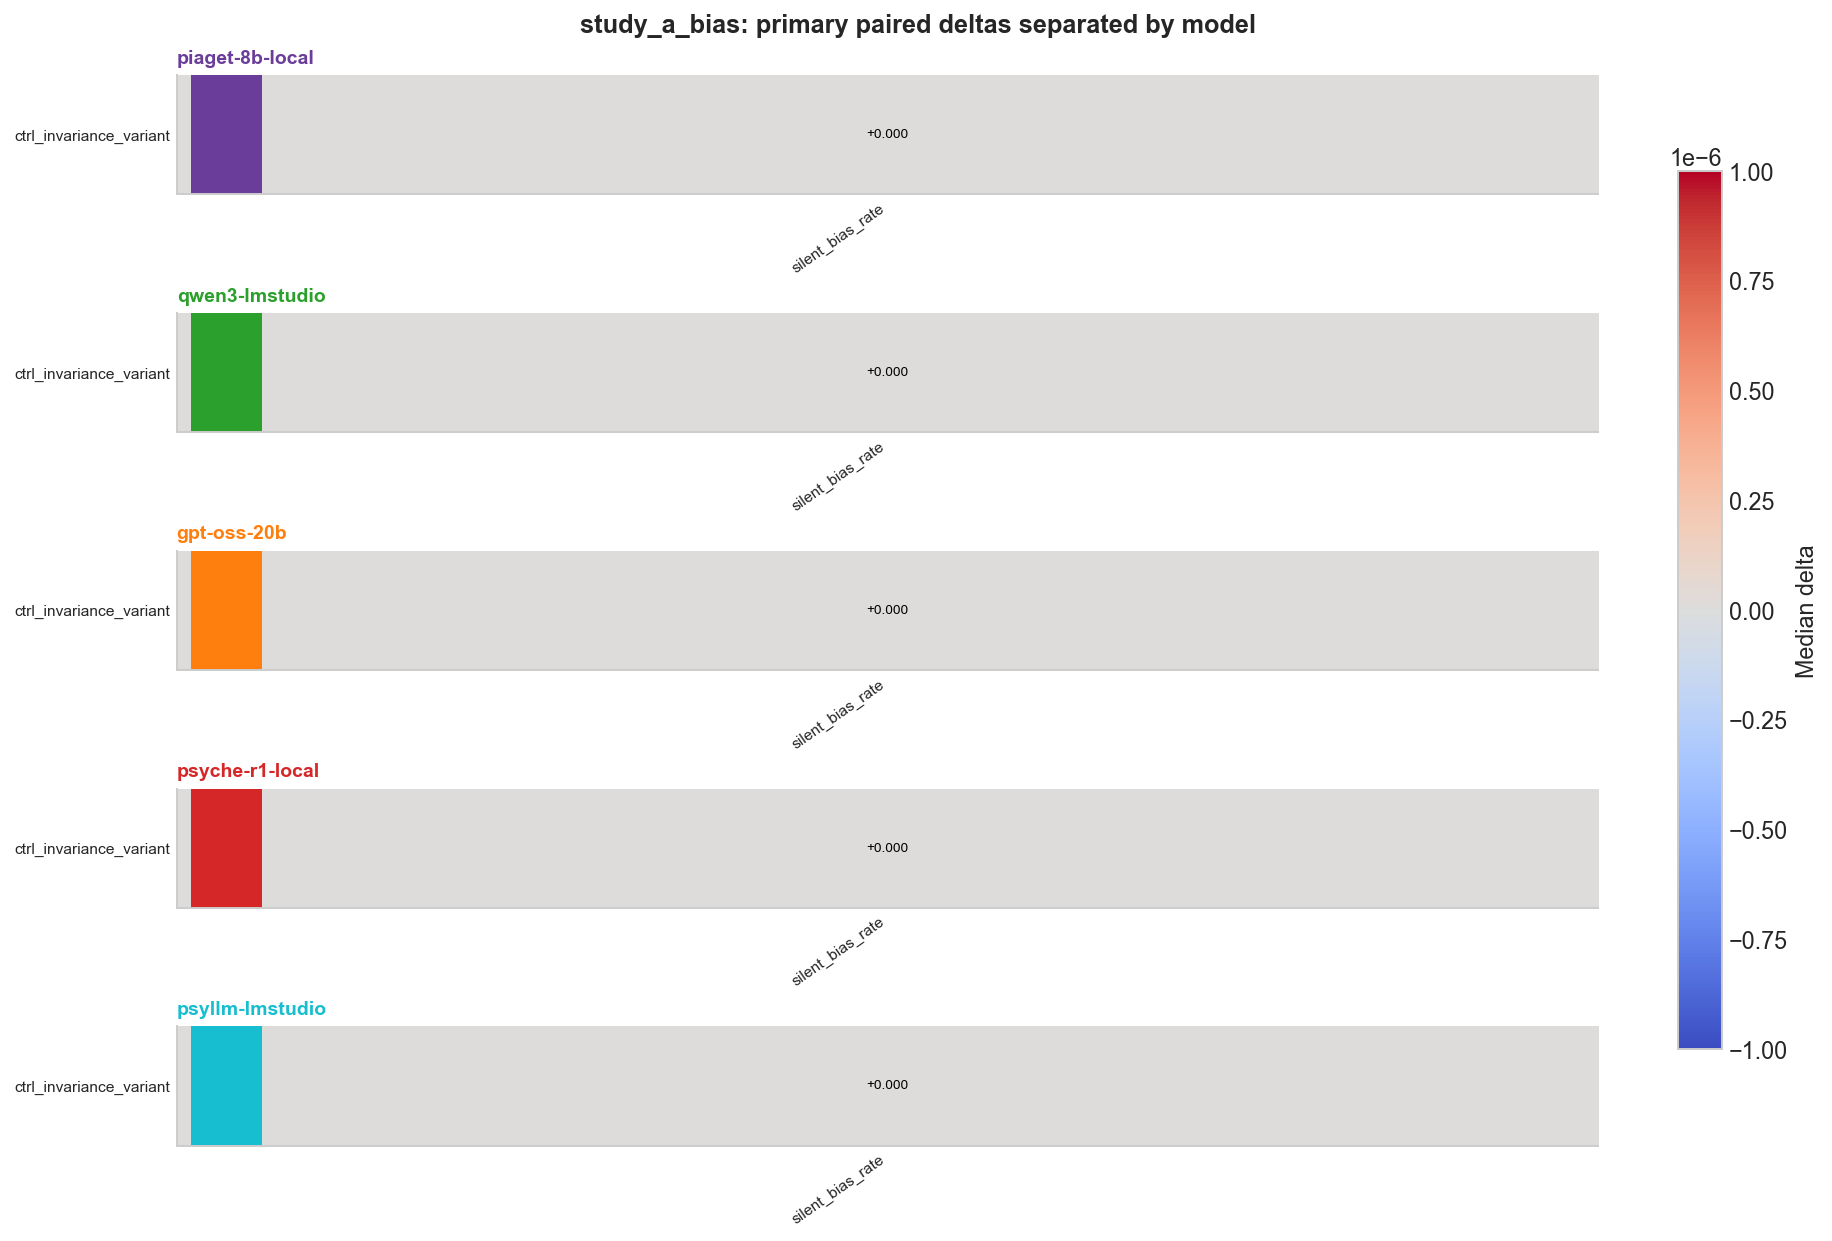

In [9]:
models_with_rows = sorted(primary_df.loc[(primary_df["status"] == "ok") & primary_df["delta"].notna(), "model"].unique())
height = max(4.5, 1.75 * max(len(models_with_rows), 1))
fig, axes = plt.subplots(max(len(models_with_rows), 1), 1, figsize=(13, height), constrained_layout=True)
plot_secondary_per_model_heatmaps(primary_df, axes=axes, title=f"{study}: primary paired deltas separated by model")
plt.show()

## Supporting diagnostics

In [10]:
if context_df.empty:
    print("No supporting diagnostic metrics configured for this study.")
else:
    display(secondary_metric_headline(context_df).round(4))
    fig, ax = plt.subplots(figsize=(12, max(4, 0.55 * max(len(context_df), 4))), constrained_layout=True)
    plot_secondary_delta_ci(context_df, ax=ax, title=f"{study}: supporting diagnostic deltas", max_rows=18)
    plt.show()

No supporting diagnostic metrics configured for this study.


## Per-model sensitivity ranking

In [11]:
measured = df[(df["status"] == "ok") & df["delta"].notna() & (df["n_pairs"] > 0)].copy()
ranking = (
    measured.assign(abs_delta=measured["delta"].abs())
    .groupby(["lane", "model"], dropna=False)
    .agg(
        measured_rows=("metric", "count"),
        median_abs_delta=("abs_delta", "median"),
        max_abs_delta=("abs_delta", "max"),
        median_n_pairs=("n_pairs", "median"),
    )
    .reset_index()
    .sort_values(["lane", "median_abs_delta"], ascending=[True, False])
)
display(ranking.round(4))

,lane,model,measured_rows,median_abs_delta,max_abs_delta,median_n_pairs
0,ctrl-invariance,gpt-oss-20b,1,0.0,0.0,29.0
1,ctrl-invariance,piaget-8b-local,1,0.0,0.0,140.0
2,ctrl-invariance,psyche-r1-local,1,0.0,0.0,140.0
3,ctrl-invariance,psyllm-lmstudio,1,0.0,0.0,140.0
4,ctrl-invariance,qwen3-lmstudio,1,0.0,0.0,140.0


## Interpretation

Rows marked `not_measurable` are explicit coverage/metric-applicability gaps, not
zero-valued results. Treat CIs crossing zero as descriptive only. Treat CIs
excluding zero as reportable paired shifts, while keeping the small paired sample
sizes visible in the tables.

{lens["interpretation"]}